# Prithvi-EO-2.0-300M-TL + UNet + WCE — Xuân Thủy
**Bản đồ mục tiêu: 21/09/2026.** Sáu band (B02, B03, B04, B8A, B11, B12), sáu thời điểm (09/01, 26/05, 18/07, 12/08, 03/09, 21/09/2026). Có chế độ một thời điểm (chỉ 21/09) để đối chứng.

**Khác notebook UPerNet trước:** chỉ đổi decoder sang **UNet** (TerraTorch `UNetDecoder`, kênh `[512, 256, 128, 64]`). Encoder, readout ngày mục tiêu, dữ liệu, split, patch, lịch batch, seed, WCE, optimizer và quy tắc chọn checkpoint giữ nguyên, để so sánh UNet với UPerNet trên cùng điều kiện.

**Cách chạy:** **Runtime → Change runtime type → GPU**, chạy các ô theo thứ tự. Ảnh: `MyDrive/Prithvi_Colab/data`. Kết quả: `MyDrive/Prithvi_Colab/runs/<experiment_id>` — thư mục run riêng, không đụng run UPerNet cũ.

**Trạng thái:** chưa huấn luyện pretrained 300M trên GPU với UNet. Chưa có cloud mask (ảnh 12/08 có mây trong AOI), DN offset −1000 là giả định chưa xác minh đủ metadata, nhãn lịch sử chưa rõ ngày. Kết quả mặc định là **bản đồ thử nghiệm**.

### Kiến trúc
```text
Input  [B, 6 band, 6 thời điểm, 224, 224]
 → Prithvi-EO-2.0-300M-TL (mã hóa chung không gian–thời gian, kèm ngày chụp + vị trí)
 → lấy token 4 tầng [5, 11, 17, 23] → ReshapeTokensToImage
 → TargetTimeSlice: giữ token ngày 21/09 (đã attention với cả chuỗi)
 → LearnedInterpolateToPyramidal: 4 mức 56/28/14/7 pixel token
 → UNet decoder (skip connection, upsample từng bước) → head 11 lớp
Output [B, 11, 224, 224]
```
UNet ở đây là **decoder** trên encoder Prithvi, không phải U-Net 10 band cũ. ViT cho các tầng cùng lưới 14×14, nên neck pyramid tạo các mức phân giải cho skip connection. BatchNorm của UNet được đổi sang GroupNorm vì micro-batch = 1. Readout ngày mục tiêu là điều chỉnh của dự án, cần đánh giá thực nghiệm.

## 1. Kết nối Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cài thư viện và helper theo commit cố định
Giữ torch/torchvision CUDA của Colab. Phiên bản thực tế được ghi vào run lock. Lần đầu tải checkpoint pretrained (~1,3 GB).

In [ ]:
import subprocess,sys
from pathlib import Path
WORK=Path('/content/prithvi_xtseg_unet_workspace')
WORK.mkdir(parents=True,exist_ok=True)
requirements=['terratorch==1.2.12','torchgeo==0.9.0','timm==1.0.30',
              'huggingface-hub==1.33.0','rasterio==1.5.2','pandas==2.2.3',
              'numpy==2.3.5','einops==0.8.2','matplotlib>=3.8,<4',
              'PyYAML>=6,<7','geopandas>=1,<2','tqdm>=4.66,<5']
subprocess.run([sys.executable,'-m','pip','install','-q',*requirements],check=True)
BASELINE_COMMIT='0775770ae87b83b7d2982ed727226128685f3fba'
BASELINE=WORK/'public_baseline'
if not BASELINE.exists():
    subprocess.run(['git','clone','https://github.com/hongphuc-maker/xuan-thuy-dmi-segmentation.git',str(BASELINE)],check=True)
subprocess.run(['git','-C',str(BASELINE),'checkout','--detach',BASELINE_COMMIT],check=True)
head=subprocess.check_output(['git','-C',str(BASELINE),'rev-parse','HEAD'],text=True).strip()
assert head==BASELINE_COMMIT
subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','-e',str(BASELINE)],check=True)
sys.path.insert(0,str(BASELINE/'src'))
print('Helper commit:',head)

Helper commit: 0775770ae87b83b7d2982ed727226128685f3fba


## 3. Nạp gói thí nghiệm
Payload chứa module Python và hai cấu hình UNet; kiểm SHA256 trước khi giải nén.

In [ ]:
import base64,hashlib,io,zipfile
PAYLOAD_B64='...'
PAYLOAD_SHA256='906bdf518fa7d6455aa1acf63441a6c0123a3e0761cf7b33d0495dcb8b209617'
payload=base64.b64decode(PAYLOAD_B64)
assert hashlib.sha256(payload).hexdigest()==PAYLOAD_SHA256,'Payload checksum khác'
with zipfile.ZipFile(io.BytesIO(payload)) as archive:
    for entry in archive.infolist():
        destination=(WORK/entry.filename).resolve()
        if WORK.resolve() not in destination.parents:
            raise ValueError('Unsafe archive path')
    archive.extractall(WORK)
sys.path.insert(0,str(WORK))
import torch,terratorch,importlib.metadata
print({p:importlib.metadata.version(p) for p in ['torch','torchvision','terratorch','torchgeo','timm','segmentation-models-pytorch','numpy']})
print('GPU:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU — cần GPU để train')

{'torch': '2.11.0+cu130', 'torchvision': '0.26.0+cu130', 'terratorch': '1.2.12', 'torchgeo': '0.9.0', 'timm': '1.0.30', 'segmentation-models-pytorch': '0.5.0', 'numpy': '2.3.5'}
GPU: Tesla T4


## 4. Cấu hình
`multitemporal` (mặc định): 6 ngày → bản đồ 21/09. `single`: chỉ 21/09, cùng mask/split/patch/batch/seed. Mỗi lần chạy notebook chỉ train một chế độ.

`DN_OFFSET=-1000` giữ như notebook UPerNet để so sánh công bằng. Chỉ đổi khi đã xác nhận metadata nguồn, và khi đổi phải dùng `RUN_SUFFIX` mới. `CLOUD_MASKS` dạng `{date: {"path": ..., "sha256": ...}}`, cần đủ sáu ngày, căn đúng lưới 10 m bằng nearest-neighbor.

In [ ]:
import json,re
MODE='multitemporal'             # 'multitemporal' hoặc 'single'
RUN_SUFFIX=''                    # ví dụ '_scl_v2' khi đổi cấu hình
DATA_ROOT=Path('/content/drive/MyDrive/Prithvi/Prithvi_Colab/data')
RUNS_ROOT=Path('/content/drive/MyDrive/Prithvi/Prithvi_Colab/runs')
DN_OFFSET=-1000.0
OFFSET_CONFIRMED=False
CLOUD_MASKS={}

assert MODE in {'multitemporal','single'}
assert re.fullmatch(r'[A-Za-z0-9_-]*',RUN_SUFFIX),'Suffix chỉ dùng chữ, số, dấu _ hoặc -'
config=json.loads((WORK/f'experiment_unet_{MODE}.json').read_text(encoding='utf-8'))
assert config['model']['decoder']=='UNetDecoder'
config['experiment_id']+=RUN_SUFFIX
config['radiometry']['dn_offset']=DN_OFFSET
config['radiometry']['confirmed_from_export_code']=OFFSET_CONFIRMED
if DN_OFFSET==0:
    config['radiometry']['provenance']='Assumption/user verification: export already harmonized, no further DN offset'
config['cloud_masks']=CLOUD_MASKS
if CLOUD_MASKS:
    assert set(CLOUD_MASKS)=={x['date'] for x in config['images']},'Cần SCL cho cả sáu ảnh'
    config['quality_status']='All six SCL masks supplied, clear-code intersection; residual clouds not independently verified'
CONFIG_PATH=WORK/'effective_experiment.json'
CONFIG_PATH.write_text(json.dumps(config,ensure_ascii=False,indent=2),encoding='utf-8')
RUN_ROOT=RUNS_ROOT/config['experiment_id']
print('Chế độ:',MODE,'| decoder:',config['model']['decoder'],config['model']['decoder_channels'])
print('Các ngày:',config['active_dates'],'→ mục tiêu',config['target_date'])
print('Run:',RUN_ROOT)

Chế độ: multitemporal | decoder: UNetDecoder [512, 256, 128, 64]
Các ngày: ['2026-01-09', '2026-05-26', '2026-07-18', '2026-08-12', '2026-09-03', '2026-09-21'] → mục tiêu 2026-09-21
Run: /content/drive/MyDrive/Prithvi/Prithvi_Colab/runs/P2_multitemporal6_sep21_UNet_WCE


## 5. Kiểm tra dữ liệu, split không gian, lấy mẫu
Weight WCE chỉ tính từ pixel train. Nhãn 0 bỏ qua. Train/validation không chung pixel đầu vào; chỉ chấm điểm validation core.

/content/prithvi_xtseg_unet_workspace/prithvi_xtseg/data.py:123: UserWarning: No cloud/SCL masks: nodata validity is not cloud validity; exploratory experiment.
  warnings.warn("No cloud/SCL masks: nodata validity is not cloud validity; exploratory experiment.")
/content/prithvi_xtseg_unet_workspace/prithvi_xtseg/data.py:125: UserWarning: Radiometric offset is an explicit assumption; verify export code before scientific reporting.
  warnings.warn("Radiometric offset is an explicit assumption; verify export code before scientific reporting.")


,date,file,valid_pixels,sha256,cloud_mask_available
0,2026-01-09,Sentinel2_2026-01-09_S2B_MSIL2A_20260109T_HSTD...,1471398,50bc6049e2ceae1cd92f15d880c9d94d8c7727b4cb97c3...,False
1,2026-05-26,Sentinel2_2026-05-26_S2A_MSIL2A_20260526T_HSTD...,1471306,9d4f4af0393b411759668173452cc5df658d895b5ccfbf...,False
2,2026-07-18,Sentinel2_2026-07-18_S2B_MSIL2A_20260718T_HSTD...,1471392,6fa20e2ec4f9dc73999d8b2e3ffd35ea670f4b7109507c...,False
3,2026-08-12,Sentinel2_2026-08-12_S2C_MSIL2A_20260812T_HSTD...,1471400,21a57a5432f684165b15fa8a6f52f8e7b103a9dc03a6a2...,False
4,2026-09-03,Sentinel2_2026-09-03_S2A_MSIL2A_20260903T_HSTD...,1471393,df112425707fe4fcc301d295c07c307f416ee1cbbd196d...,False
5,2026-09-21,Sentinel2_2026-09-21_S2C_MSIL2A_20260921T_HSTD...,1471243,d924eb0e19175ba0c38d1fc058516783778bf39fb4b272...,False


,code,class,train_pixels,WCE_weight
0,1,Anm,87083,0.499391
1,2,Bgt,190976,0.337223
2,3,Dc,94719,0.478838
3,4,Dnn,183098,0.344402
4,5,DK,1015,2.541697
5,6,trống,1495,2.541697
6,7,Gt,4666,2.157420
7,8,Rnm,84044,0.508339
8,9,Stx,48474,0.669349
9,10,Vbn,326520,0.257900


{'shape': [1374, 1821], 'common_labeled_pixels': 1471132, 'train_pixels': 1071386, 'validation_pixels': 294156, 'n_patches': 4992, 'n_batches': 312, 'n_validation_windows': 36, 'shared_input_pixels': 0}


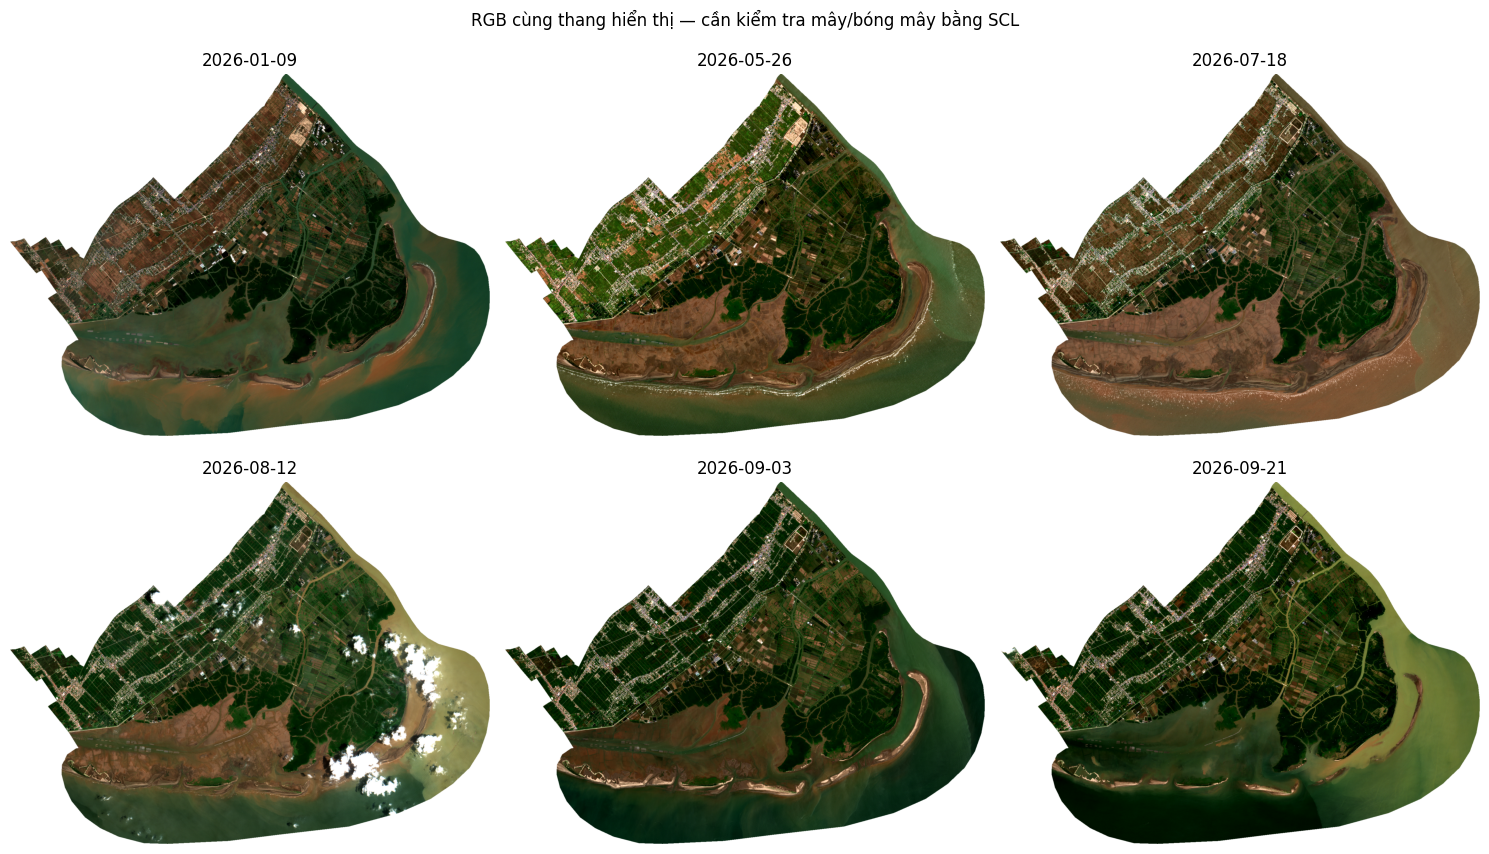

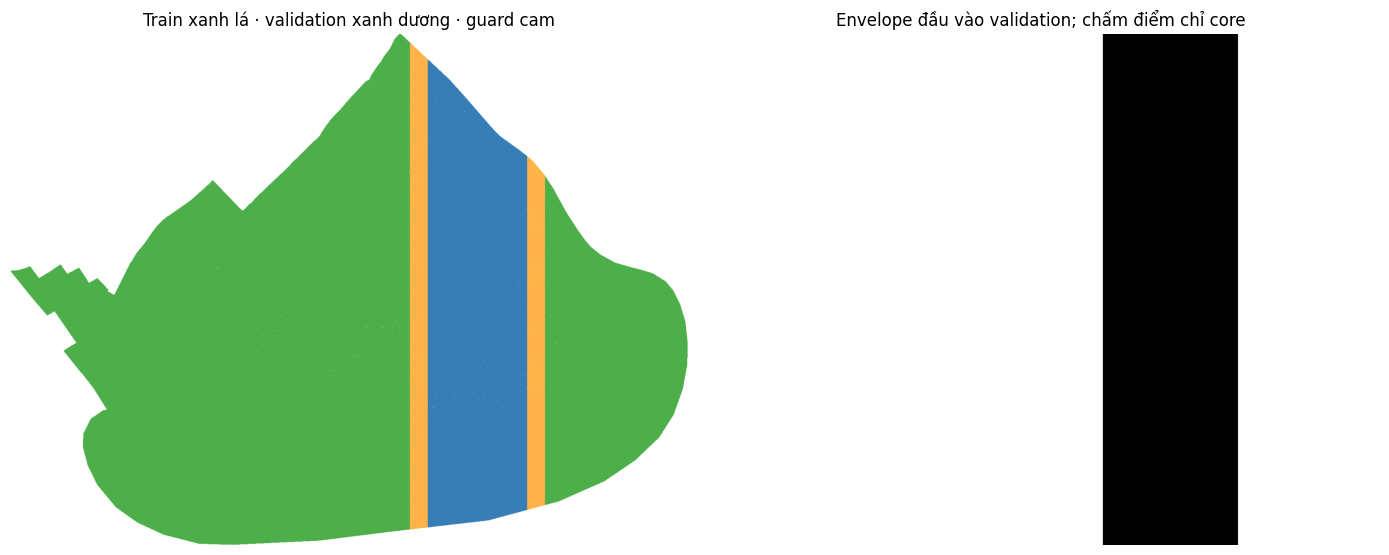

In [ ]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
from prithvi_xtseg.training import open_experiment
from prithvi_xtseg.reporting import show_inputs,show_split,show_history,show_map,compare_validation
experiment=open_experiment(CONFIG_PATH,DATA_ROOT,RUN_ROOT)
audit=json.loads((RUN_ROOT/'prepared'/'DATA_AUDIT.json').read_text())
display(pd.DataFrame(audit['images']))
display(pd.DataFrame({'code':range(1,12),'class':[config['class_map'][str(i)] for i in range(1,12)],
                      'train_pixels':audit['train_class_counts'],'WCE_weight':audit['class_weights']}))
print({k:audit[k] for k in ['shape','common_labeled_pixels','train_pixels','validation_pixels',
                          'n_patches','n_batches','n_validation_windows','shared_input_pixels']})
assert audit['shared_input_pixels']==0
fig=show_inputs(experiment);plt.show();plt.close(fig)
fig=show_split(experiment);plt.show();plt.close(fig)

## 6. Nạp pretrained + smoke test GPU
Kiểm tra strict loading, cấu trúc UNet decoder, output 11 lớp, loss/gradient hữu hạn và bộ nhớ GPU cực đại. **Đây là lần đầu UNet decoder chạy với encoder 300M thật** — nếu ô này lỗi shape hoặc thiếu bộ nhớ, dừng lại và báo lỗi, không tự đổi kiến trúc.

In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError('Chọn Runtime → Change runtime type → GPU rồi chạy lại')
model=experiment.load_model(pretrained=True)
print(type(model.decoder).__name__,'| decoder params:',sum(p.numel() for p in model.decoder.parameters()))
assert type(model.decoder).__name__=='UNetDecoder'
assert not any(isinstance(m,torch.nn.BatchNorm2d) for m in model.modules()),'Còn BatchNorm'
print('Tổng tham số:',sum(p.numel() for p in model.parameters()))
smoke=experiment.smoke_test()
display(smoke)
assert smoke['input_shape']==[1,6,len(config['active_dates']),224,224]
assert smoke['output_shape']==[1,11,224,224]
print('Smoke test đạt. Bộ nhớ cực đại (GB):',smoke['peak_cuda_gb'])

## 7. Fine-tune bằng WCE
Batch hiệu dụng 16 (micro-batch 1, accumulation đúng mẫu số WCE). AdamW: encoder 1e-5, decoder 1e-4. Tối đa 3.120 step, validation mỗi 156, checkpoint mỗi 78, early stopping patience 6. Bị ngắt thì chạy lại từ ô 1 với cùng cấu hình — tự resume từ `latest_resume.pt`.

Chọn checkpoint theo macro-F1 11 lớp; gate: dự đoán đủ 11 lớp và recall lớp 5/6/7 ≥ 0,05. Không dùng điểm kiểm chứng để chọn mô hình.

Optimizer steps:   0%|          | 0/2730 [00:00<?, ?it/s]

Step 468: val F1=0.4037, IoU=0.3254, gate=False
Step 624: val F1=0.4030, IoU=0.3216, gate=False
Step 780: val F1=0.4117, IoU=0.3334, gate=False
Step 936: val F1=0.4152, IoU=0.3357, gate=False
Step 1092: val F1=0.4261, IoU=0.3447, gate=False
Step 1248: val F1=0.4345, IoU=0.3505, gate=False
Step 1404: val F1=0.4344, IoU=0.3486, gate=False
Step 1560: val F1=0.4279, IoU=0.3457, gate=False
Step 1716: val F1=0.4330, IoU=0.3470, gate=False
Step 1872: val F1=0.4374, IoU=0.3536, gate=False
Step 2028: val F1=0.4334, IoU=0.3510, gate=False
Step 2184: val F1=0.4429, IoU=0.3563, gate=False
Step 2340: val F1=0.4412, IoU=0.3558, gate=False
Step 2496: val F1=0.4396, IoU=0.3553, gate=False
Step 2652: val F1=0.4389, IoU=0.3532, gate=False
Step 2808: val F1=0.4398, IoU=0.3541, gate=False
Step 2964: val F1=0.4363, IoU=0.3509, gate=False
Step 3120: val F1=0.4364, IoU=0.3514, gate=False


{'step': 3120,
 'completed': True,
 'early_stopped': True,
 'best_F1': 0.44292418407295797,
 'best_accepted_F1': -1.0,
 'method_hash': 'd4f8bef93e89450b9935fd1f982d4c3ef25d23b7386b225cb98c8e27b288021c'}

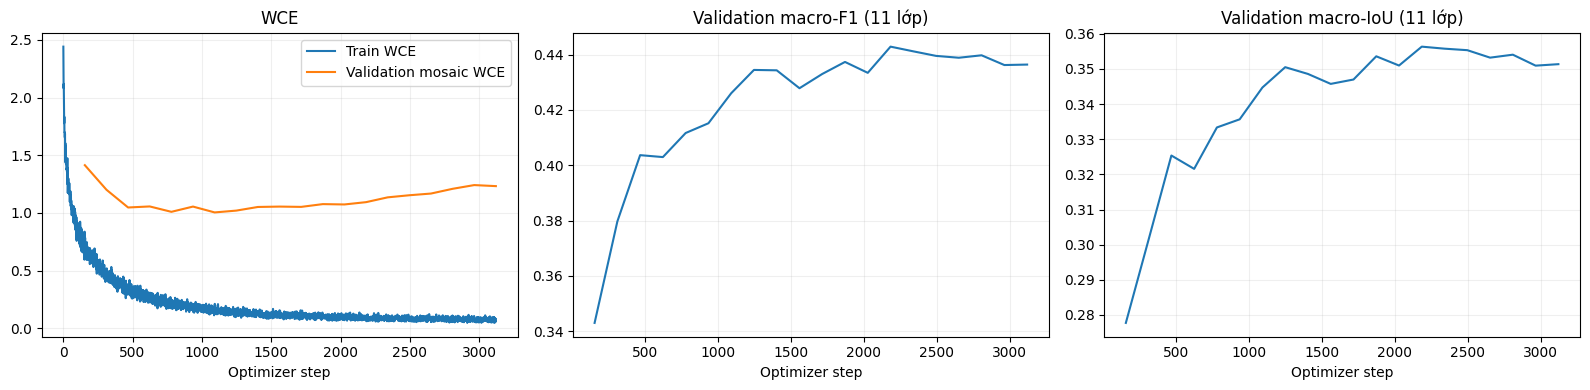

,code,class,support,predicted,precision,recall,F1,IoU
0,1,Anm,119658,118433,0.921947,0.912509,0.917204,0.847070
1,2,Bgt,9260,14183,0.483466,0.740497,0.584993,0.413421
2,3,Dc,899,1000,0.458000,0.509455,0.482359,0.317835
3,4,Dnn,782,3264,0.229167,0.956522,0.369748,0.226804
4,5,DK,1662,8,0.750000,0.003610,0.007186,0.003606
5,6,trống,652,0,0.000000,0.000000,0.000000,0.000000
6,7,Gt,510,91,0.538462,0.096078,0.163062,0.088768
7,8,Rnm,66690,72457,0.861573,0.936077,0.897281,0.813699
8,9,Stx,31491,17511,0.626578,0.348417,0.447818,0.288509
9,10,Vbn,60073,59305,0.932333,0.920413,0.926335,0.862778


In [ ]:
training_result=experiment.train()
display(training_result)
fig=show_history(RUN_ROOT)
fig.savefig(RUN_ROOT/'training_curves.png',dpi=160,bbox_inches='tight')
plt.show();plt.close(fig)
display(pd.read_csv(RUN_ROOT/'latest_validation_per_class.csv'))

## 8. Xuất GeoTIFF bản đồ 21/09
Cửa sổ 224, stride 112, trung bình xác suất. Nhãn 1–11, nodata 0. Confidence/entropy chưa calibration.

Acceptance gate failed: output is an exploratory map, not an accepted model.


Probability mosaic:   0%|          | 0/165 [00:00<?, ?it/s]

{'file': 'best_any.pt',
 'acceptance_passed': False,
 'summary': {'OA': 0.8383000856688287,
  'macro_F1_11': 0.44292418407295797,
  'macro_IoU_11': 0.35634221276673056,
  'predicted_classes': 10,
  'n_pixels': 294156,
  'WCE': 1.093256950378418,
  'acceptance_passed': False,
  'step': 2184}}

{'method_hash': 'd4f8bef93e89450b9935fd1f982d4c3ef25d23b7386b225cb98c8e27b288021c',
 'checkpoint_sha256': 'cb228899ad7503fe7b45a3301ea2a9e41247abbf18120582fa1142061a374988',
 'target_date': '2026-09-21',
 'valid_pixels': 1471132,
 'artifacts': {'classes_sep21_2026.tif': '76f97d0ec7657afd96837b1db4321fcfc8a53330cdbf4680b0737103b237c2ab',
  'max_softmax_uncalibrated.tif': 'fbee50bdcdf880c3728dd606c71a0a920b69a9a56e4ecf1e5dd4f90e3ce6d326',
  'entropy_uncalibrated.tif': '1cac0b2aad532bf21dd6dc41628261139b441fb4150012447d422f92e9cd4b9f',
  'common_validity.tif': 'e6a8feee6b9cd806b95a440b87294894ba4575b0b3b6819ebbe9a57e834406b2'},
 'note': 'Target September map; not validated against date-matched September ground truth'}

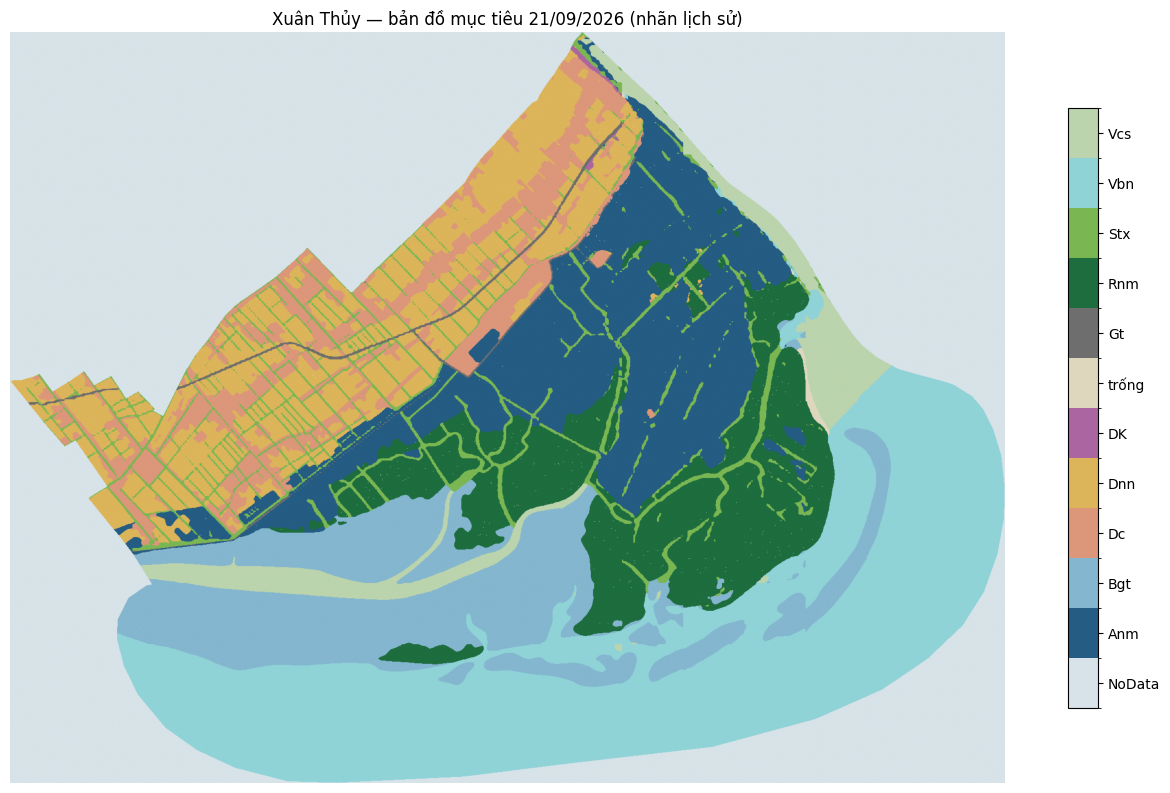

GeoTIFF: /content/drive/MyDrive/Prithvi_Colab/runs/P2_multitemporal6_sep21_UNet_WCE/map/classes_sep21_2026.tif


In [ ]:
map_result=experiment.map()
display(json.loads((RUN_ROOT/'MODEL_SELECTION.json').read_text()))
display(map_result)
fig=show_map(experiment)
fig.savefig(RUN_ROOT/'map_preview.png',dpi=180,bbox_inches='tight')
plt.show();plt.close(fig)
print('GeoTIFF:',RUN_ROOT/'map'/'classes_sep21_2026.tif')

## 9. So sánh UNet và UPerNet
Đọc các run đã có `MODEL_SELECTION.json`; run chưa có sẽ bị bỏ qua. Cùng validation core và nhãn lịch sử. Nếu các run khác radiometry/SCL/suffix, không quy chênh lệch chỉ cho decoder hoặc thời gian.

- P0 / P1: UPerNet, 1 / 6 thời điểm (notebook trước)
- P3 / P2: UNet, 1 / 6 thời điểm (notebook này)

In [ ]:
runs=['P0_single_sep21_WCE','P1_multitemporal6_sep21_WCE',
      'P3_single_sep21_UNet_WCE','P2_multitemporal6_sep21_UNet_WCE']
comparison=compare_validation([RUNS_ROOT/(r+RUN_SUFFIX) for r in runs])
if len(comparison):
    comparison.insert(1,'decoder',['UNet' if 'UNet' in r else 'UPerNet' for r in comparison.run])
    display(comparison[['run','decoder','T','acceptance_passed','macro_F1_11','macro_IoU_11','OA','WCE','predicted_classes']])
    comparison.to_csv(RUN_ROOT/'comparison_validation.csv',index=False)
else:
    print('Chưa có run nào hoàn tất model selection.')

## 10. Tùy chọn: đối chiếu điểm cũ (sau khi chốt bản đồ)
Mặc định tắt. Chỉ báo **agreement với điểm cũ**, chưa phải accuracy tháng 9.

In [ ]:
EVALUATE_OLD_POINTS=True
POINTS_ROOT=Path('/content/drive/MyDrive/Prithvi/Prithvi_Colab/data')
if EVALUATE_OLD_POINTS:
    from prithvi_xtseg.inference import evaluate_reference_points
    agreement=evaluate_reference_points(experiment.scene,RUN_ROOT,POINTS_ROOT,confirm=True)
    display(agreement)
    display(pd.read_csv(RUN_ROOT/'reference_point_agreement'/'per_class.csv'))
else:
    print('Bỏ qua đối chiếu điểm cũ.')

{'OA': 0.9218146718146718,
 'macro_F1_11': 0.5747622905520205,
 'macro_IoU_11': 0.5344385399511759,
 'predicted_classes': 9,
 'n_pixels': 1036,
 'macro_F1_represented_classes': 0.9031978851531751,
 'input_points': 1037,
 'excluded_points': 1,
 'interpretation': 'Agreement with previously used reference points; September accuracy not established',
 'map_sha256': '76f97d0ec7657afd96837b1db4321fcfc8a53330cdbf4680b0737103b237c2ab',
 'method_hash': 'd4f8bef93e89450b9935fd1f982d4c3ef25d23b7386b225cb98c8e27b288021c',
 'artifacts': {'points.csv': '5d67307babfb6f5a79ec5b15f5feb927198e257395a4927be957fd17bb3a7d9d',
  'per_class.csv': 'ac6da7ce42e6c15347004e1950429a220fbdf7cf26f2b993ef52a58afa42e1ec',
  'confusion.csv': '2e6176e1525c63fe51aa070c01f92e2ba0b598de06217b27c17179d4a7b061bd'}}

,code,class,support,predicted,precision,recall,F1,IoU
0,1,Anm,161,164,0.963415,0.981366,0.972308,0.946108
1,2,Bgt,134,143,0.937063,1.000000,0.967509,0.937063
2,3,Dc,0,18,0.000000,0.000000,0.000000,0.000000
3,4,Dnn,240,254,0.937008,0.991667,0.963563,0.929688
4,5,DK,0,0,0.000000,0.000000,0.000000,0.000000
5,6,trống,0,0,0.000000,0.000000,0.000000,0.000000
6,7,Gt,0,4,0.000000,0.000000,0.000000,0.000000
7,8,Rnm,198,198,0.984848,0.984848,0.984848,0.970149
8,9,Stx,100,65,0.846154,0.550000,0.666667,0.500000
9,10,Vbn,103,114,0.903509,1.000000,0.949309,0.903509


## Giới hạn diễn giải
Baseline commit `0775770ae87b83b7d2982ed727226128685f3fba`, model revision `63adbd39c271da4c42f447e69b1a7c91a338cdc9`, TerraTorch 1.2.12 `UNetDecoder`. Chưa có benchmark nào chứng minh UNet hay UPerNet tốt hơn trên Xuân Thủy — đó là mục đích của so sánh ở ô 9. Trước khi báo cáo khoa học: xác minh offset/scale từ metadata, bổ sung cloud mask (nhất là 12/08), và có nhãn/điểm đúng tháng 9.